In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import MobileNetV2
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import cv2

In [2]:
# Parameters
img_height, img_width = 300, 300
batch_size = 32
epochs =  100

# Define the ImageDataGenerator for training and set up for splitting
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of data for validation/test split
)

In [ ]:
# Create training and validation/test generators
train_data = datagen.flow_from_directory(
    "/Downloads/Hand_Gesture_Dataset",  # This directory has "on" and "off" subfolders
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',  # 80% for training
    shuffle=True
)

# Split validation and test data
val_test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.5)
validation_data = val_test_datagen.flow_from_directory(
    "/Downloads/Hand_Gesture_Dataset",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',  # 10% for validation
    shuffle=True
)

test_data = val_test_datagen.flow_from_directory(
    "/Downloads/Hand_Gesture_Dataset",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',  # 10% for testing
    shuffle=False
)

Found 1060 images belonging to 2 classes.
Found 662 images belonging to 2 classes.
Found 662 images belonging to 2 classes.


In [4]:
# Check class imbalance
class_counts = train_data.classes
unique, counts = np.unique(class_counts, return_counts=True)
class_labels = list(train_data.class_indices.keys())
print("Class distribution:", dict(zip(class_labels, counts)))

# Calculate class weights to handle class imbalance
class_weight = compute_class_weight(class_weight='balanced', classes=np.unique(class_counts), y=class_counts)
class_weight_dict = dict(enumerate(class_weight))
print("Class weights:", class_weight_dict)

Class distribution: {'off': 576, 'on': 484}
Class weights: {0: 0.9201388888888888, 1: 1.0950413223140496}


In [ ]:
# Set up a data augmentation strategy for the minority class
if counts[0] < counts[1]:  # If "on" is the minority class
    minority_class = 'on'
else:
    minority_class = 'off'

# Additional augmentation for the minority class
minority_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    validation_split=0.2  # Matches the main train-validation split
)

# Load additional augmented data only for the minority class
minority_data = minority_datagen.flow_from_directory(
    "/Downloads/Hand_Gesture_Dataset",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=[minority_class],
    shuffle=True
)

Found 576 images belonging to 1 classes.


In [6]:
# Define a combined generator function with sample weighting for imbalance handling
def combined_generator(main_gen, minority_gen, class_weight_dict, ratio=0.5):
    while True:
        # Fetch a batch from each generator
        main_batch = next(main_gen)
        minority_batch = next(minority_gen)
        
        # Choose batch based on ratio
        if np.random.rand() < ratio:
            batch_x, batch_y = minority_batch
        else:
            batch_x, batch_y = main_batch

        # Adjust weights for imbalance
        sample_weights = np.array([class_weight_dict[int(label)] for label in batch_y])
        
        yield batch_x, batch_y, sample_weights

In [ ]:
# Load MobileNetV2 with pre-trained weights and exclude the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='sigmoid')(x)  # Binary classification

# Combine the base model and custom layers
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# Train the model without `class_weight` in `fit`, using sample weights instead
history = model.fit(
    combined_generator(train_data, minority_data, class_weight_dict),
    validation_data=validation_data,
    epochs=epochs,
    steps_per_epoch=train_data.samples // batch_size
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test accuracy: {test_accuracy:.2f}")

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6134 - loss: 0.7468

C:\Users\hylmi\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


33/33 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6149 - loss: 0.7448 - val_accuracy: 0.5438 - val_loss: 0.6388
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8357 - loss: 0.4499 - val_accuracy: 0.5438 - val_loss: 0.6275
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8117 - loss: 0.4106 - val_accuracy: 0.8656 - val_loss: 0.4500
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8100 - loss: 0.4337 - val_accuracy: 0.9366 - val_loss: 0.3577
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8165 - loss: 0.4039 - val_accuracy: 0.9109 - val_loss: 0.3314
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8936 - loss: 0.3117 - val_accuracy: 0.8912 - val_loss: 0.3164
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8710 - loss: 0.3333 - val_accuracy: 0.9517 - val_loss: 0.2844
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8894 - loss: 0.2981 - val_accuracy: 0.8444 - val_loss: 0.3

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict on the test set
y_pred_probs = model.predict(test_data)  # Get probabilities
y_pred = (y_pred_probs > 0.5).astype("int32")  # Convert probabilities to binary predictions
y_true = test_data.classes  # True labels

# Compute various performance metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=1)
recall = recall_score(y_true, y_pred, zero_division=1)
f1 = f1_score(y_true, y_pred, zero_division=1)

# Print the classification report for detailed per-class metrics
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Off', 'On']))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Print individual metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 723ms/step
Classification Report:
              precision    recall  f1-score   support

         Off       0.92      1.00      0.95       360
          On       1.00      0.89      0.94       302

    accuracy                           0.95       662
   macro avg       0.96      0.94      0.95       662
weighted avg       0.95      0.95      0.95       662

Confusion Matrix:
[[359   1]
 [ 33 269]]
Accuracy: 0.95
Precision: 1.00
Recall: 0.89
F1 Score: 0.94


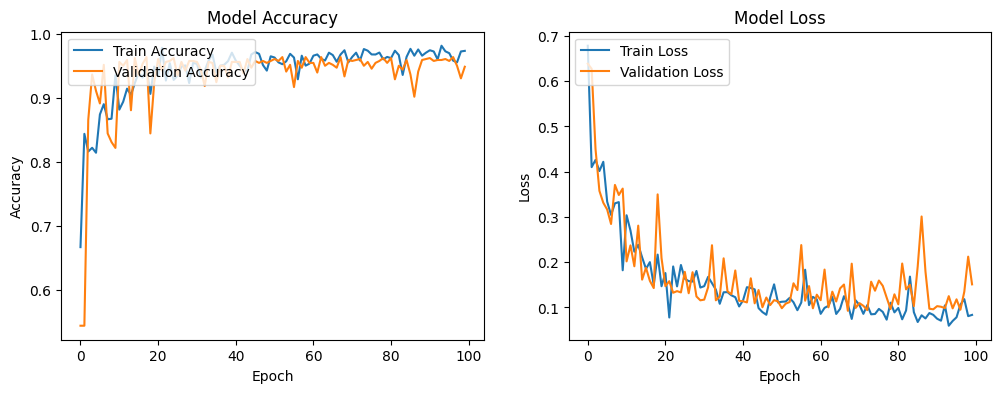

In [10]:
# Optional: Plot training history (loss and accuracy)
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.show()

In [ ]:
def test_single_image(model, img_path, target_size=(img_height, img_width)):
    """
    Function to test a single image with the trained model.

    Parameters:
    - model: Trained Keras model.
    - img_path: Path to the image file.
    - target_size: Target size for resizing the image to match model input.

    Returns:
    - Prediction: Class label ("on" or "off") for the image.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale to match training preprocessing

    # Predict with the model
    prediction = model.predict(img_array)

    # Convert prediction to class label
    if prediction[0] > 0.5:
        return "on"  # Adjust this based on the class labels in your model
    else:
        return "off"

# Example usage - off
img_path = "/Downloads/Hand_Gesture_Dataset/off/S1 - G11 - 22-color.png"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

# Example usage - on
img_path = "/Downloads/Hand_Gesture_Dataset/on/S1- G9 - 30-color.png"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

# Example usage - on
img_path = "/Downloads/Hand_Gesture_Dataset/on/S1- G9 - 28-color.png"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

# Example usage - Real time on
img_path = "/Pictures/Camera Roll/WIN_20241105_02_54_27_Pro.jpg"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

# Example usage - Real time off
img_path = "/Pictures/Camera Roll/WIN_20241104_18_44_46_Pro.jpg"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

# Example usage - Real time off
img_path = "/Downloads/Line/42398.jpg"
result = test_single_image(model, img_path)
print(f"The predicted class for the image is: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
The predicted class for the image is: off
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
The predicted class for the image is: on
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The predicted class for the image is: on
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
The predicted class for the image is: on
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The predicted class for the image is: off
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
The predicted class for the image is: off


In [12]:
# Assuming `model` is your MobileNetV2 model
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model to a file
with open("mobilenetv2_gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model saved as mobilenetv2_gesture_model.tflite")

INFO:tensorflow:Assets written to: C:\Users\hylmi\AppData\Local\Temp\tmpiti9ej0j\assets


INFO:tensorflow:Assets written to: C:\Users\hylmi\AppData\Local\Temp\tmpiti9ej0j\assets


Saved artifact at 'C:\Users\hylmi\AppData\Local\Temp\tmpiti9ej0j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1687750612112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750614992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750614032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750615760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750613456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750615376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750614800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750614224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750613648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1687750616336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16877